# Basecamp Brew Co. — 비즈니스 분석 보고서
판매 및 고객 데이터 12개월 종합 분석 | 생성일: 2026-05-14

In [4]:
# ① 이 셀의 경로/목표만 바꾸면 다른 데이터에도 재사용 가능
BASE_DIR       = r'G:\내 드라이브\강의자료\Vibe_Coding\Datascience\Test\15_Basecamp_Brew_Analysis'
SALES_FILE     = BASE_DIR + r'\resource\sales-data.xlsx'
CUSTOMERS_FILE = BASE_DIR + r'\resource\customers.xlsx'   # None 이면 고객 분석 건너뜀
OUTPUT_DIR     = BASE_DIR + r'\output'
ANALYSIS_GOAL  = "채널별·제품별 수익성 및 최우수 고객 채널 파악"

In [5]:
import sys, os
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
font_path = r'C:\Windows\Fonts\malgun.ttf'
fm.fontManager.addfont(font_path)
matplotlib.rcParams['font.family'] = fm.FontProperties(fname=font_path).get_name()
matplotlib.rcParams['axes.unicode_minus'] = False

# workflows 모듈 임포트
sys.path.insert(0, os.path.join(BASE_DIR, 'workflows'))
from analysis_helper import load_data, profile_data, detect_anomalies, fmt_dollar, CHANNEL_COLORS
from deep_analysis import monthly_summary, channel_summary, product_summary, customer_segment_summary

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"분석 목표: {ANALYSIS_GOAL}")
print(f"출력 폴더: {OUTPUT_DIR}")

분석 목표: 채널별·제품별 수익성 및 최우수 고객 채널 파악
출력 폴더: G:\내 드라이브\강의자료\Vibe_Coding\Datascience\Test\15_Basecamp_Brew_Analysis\output


## § 1. 데이터 로드 & 품질 검사

In [6]:
# 파일 로드
df_sales = pd.read_excel(SALES_FILE, engine='openpyxl')
df_customers = pd.read_excel(CUSTOMERS_FILE, engine='openpyxl') if CUSTOMERS_FILE else None

print(f"판매 데이터: {len(df_sales):,}행 × {len(df_sales.columns)}열")
if df_customers is not None:
    print(f"고객 데이터: {len(df_customers):,}행 × {len(df_customers.columns)}열")

# 데이터 품질 리포트
profile_data('sales', df_sales)
if df_customers is not None:
    profile_data('customers', df_customers)

판매 데이터: 630행 × 10열
고객 데이터: 200행 × 8열

[데이터 품질 리포트: sales]
  총 행수: 630행 | 총 열수: 10개
  컬럼 목록: Order ID, Date, Product, Category, Channel, Quantity, Unit Price, Revenue, Cost, Profit
  중복 행: 0건
  결측값: 없음
  [날짜형 의심 컬럼]: Order ID
  [수치 컬럼 통계]
    Quantity: 합계=6,857.00 | 평균=10.88 | 최소=1.00 | 최대=78.00
    Unit Price: 합계=6,930.00 | 평균=11.00 | 최소=3.00 | 최대=28.00
    Revenue: 합계=74,428.00 | 평균=118.14 | 최소=5.00 | 최대=1,872.00
    Cost: 합계=21,246.00 | 평균=33.72 | 최소=0.80 | 최대=546.00
    Profit: 합계=53,182.00 | 평균=84.42 | 최소=4.20 | 최대=1,326.00

[데이터 품질 리포트: customers]
  총 행수: 200행 | 총 열수: 8개
  컬럼 목록: Customer ID, Name, Signup Date, Channel, Total Orders, Total Spend, Last Order Date, Repeat Customer
  중복 행: 0건
  결측값: 없음
  [날짜형 의심 컬럼]: Customer ID
  [수치 컬럼 통계]
    Total Orders: 합계=1,004.00 | 평균=5.02 | 최소=1.00 | 최대=25.00
    Total Spend: 합계=19,501.88 | 평균=97.51 | 최소=5.59 | 최대=661.60


In [7]:
# IQR 기반 이상치 탐지
anomalies = detect_anomalies('sales', df_sales)

if anomalies:
    print("\n[이상치 탐지 결과]")
    for a in anomalies:
        if 'issue' in a:
            print(f"  {a['column']}: {a['issue']} — {a['negative_count']}건 ({a['negative_pct']}%)")
        else:
            print(f"  {a['column']}: IQR 이상치 {a['outlier_count']}건 ({a['outlier_pct']}%)")
            print(f"    정상 범위: {a['lower_bound']:,.2f} ~ {a['upper_bound']:,.2f}")
else:
    print("이상치: 없음")


[이상치 탐지 결과]
  Quantity: IQR 이상치 35건 (5.6%)
    정상 범위: -11.00 ~ 29.00
  Revenue: IQR 이상치 88건 (14.0%)
    정상 범위: -95.00 ~ 233.00
  Cost: IQR 이상치 89건 (14.1%)
    정상 범위: -26.82 ~ 63.37
  Profit: IQR 이상치 87건 (13.8%)
    정상 범위: -70.00 ~ 170.00


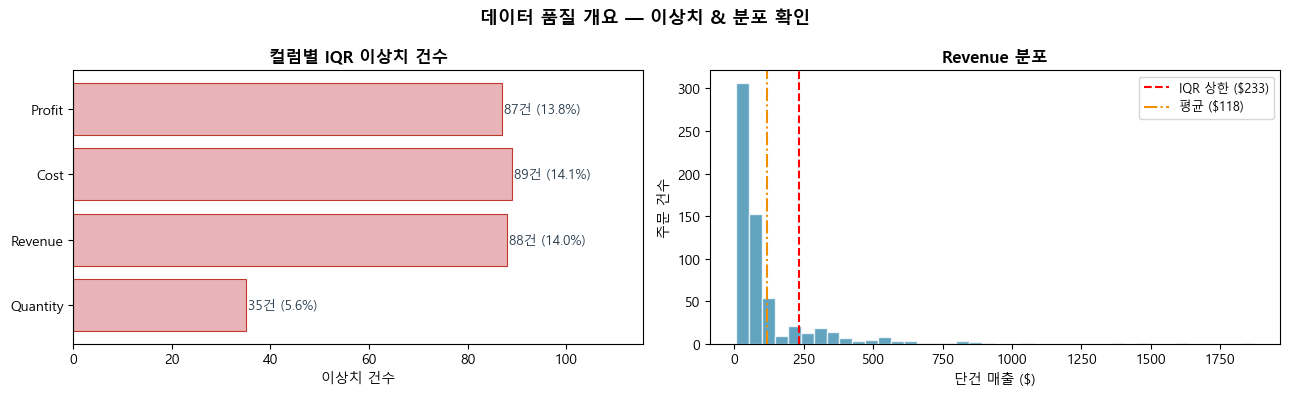

저장: G:\내 드라이브\강의자료\Vibe_Coding\Datascience\Test\15_Basecamp_Brew_Analysis\output\00_data_quality.png


In [8]:
# ── 데이터 품질 시각화 ────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# 왼쪽: 수치 컬럼별 IQR 이상치 건수
outlier_cols = ['Quantity', 'Revenue', 'Cost', 'Profit']
outlier_counts = []
for col in outlier_cols:
    s = df_sales[col].dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    cnt = int(((s < q1 - 1.5*iqr) | (s > q3 + 1.5*iqr)).sum())
    outlier_counts.append(cnt)

bar_q = ax1.barh(outlier_cols, outlier_counts, color='#E8B4B8', edgecolor='#c0392b', linewidth=0.8)
for bar, cnt in zip(bar_q, outlier_counts):
    ax1.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f'{cnt}건 ({cnt/len(df_sales)*100:.1f}%)', va='center', fontsize=9.5, color='#2c3e50')
ax1.set_title('컬럼별 IQR 이상치 건수', fontweight='bold')
ax1.set_xlabel('이상치 건수')
ax1.set_xlim(0, max(outlier_counts) * 1.3)

# 오른쪽: Revenue 분포 히스토그램
ax2.hist(df_sales['Revenue'], bins=40, color='#2E86AB', alpha=0.75, edgecolor='white')
q1v = df_sales['Revenue'].quantile(0.25)
q3v = df_sales['Revenue'].quantile(0.75)
upper_v = q3v + 1.5 * (q3v - q1v)
ax2.axvline(upper_v, color='red', linestyle='--', linewidth=1.5, label=f'IQR 상한 (${upper_v:,.0f})')
ax2.axvline(df_sales['Revenue'].mean(), color='#F18F01', linestyle='-.',
            linewidth=1.5, label=f'평균 (${df_sales["Revenue"].mean():,.0f})')
ax2.set_title('Revenue 분포', fontweight='bold')
ax2.set_xlabel('단건 매출 ($)')
ax2.set_ylabel('주문 건수')
ax2.legend(fontsize=9)

plt.suptitle('데이터 품질 개요 — 이상치 & 분포 확인', fontsize=13, fontweight='bold')
plt.tight_layout()
out_q = os.path.join(OUTPUT_DIR, '00_data_quality.png')
plt.savefig(out_q, dpi=150, bbox_inches='tight')
plt.show()
print(f"저장: {out_q}")

## § 2. 월별 매출 트렌드

In [9]:
monthly = monthly_summary(df_sales)

# 서식 표 출력
display_cols = ['MonthName', 'Orders', 'Revenue', 'Profit', 'ProfitMargin_Pct', 'Revenue_MoM_Pct']
disp = monthly[display_cols].copy()
disp.columns = ['월', '주문수', '매출', '이익', '마진(%)', 'MoM(%)']
disp['매출'] = disp['매출'].apply(fmt_dollar)
disp['이익'] = disp['이익'].apply(fmt_dollar)
print(disp.to_string(index=False))

print(f"\n총 매출: {fmt_dollar(monthly['Revenue'].sum())}")
print(f"총 이익: {fmt_dollar(monthly['Profit'].sum())}")
print(f"평균 마진: {monthly['ProfitMargin_Pct'].mean():.1f}%")

      월  주문수        매출        이익  마진(%)  MoM(%)
2025-04   45 $4,563.00 $3,233.30   70.9     NaN
2025-05   60 $6,188.00 $4,434.90   71.7    35.6
2025-06   60 $6,831.00 $4,960.80   72.6    10.4
2025-07   60 $8,509.00 $6,189.30   72.7    24.6
2025-08   60 $7,188.50 $5,269.70   73.3   -15.5
2025-09   60 $6,907.50 $4,949.70   71.7    -3.9
2025-10   60 $6,552.50 $4,591.10   70.1    -5.1
2025-11   45 $2,723.00 $1,915.10   70.3   -58.4
2025-12   45 $6,541.00 $4,622.30   70.7   140.2
2026-01   45 $6,132.00 $4,334.50   70.7    -6.3
2026-02   45 $5,812.00 $4,104.40   70.6    -5.2
2026-03   45 $6,480.50 $4,576.90   70.6    11.5

총 매출: $74,428.00
총 이익: $53,182.00
평균 마진: 71.3%


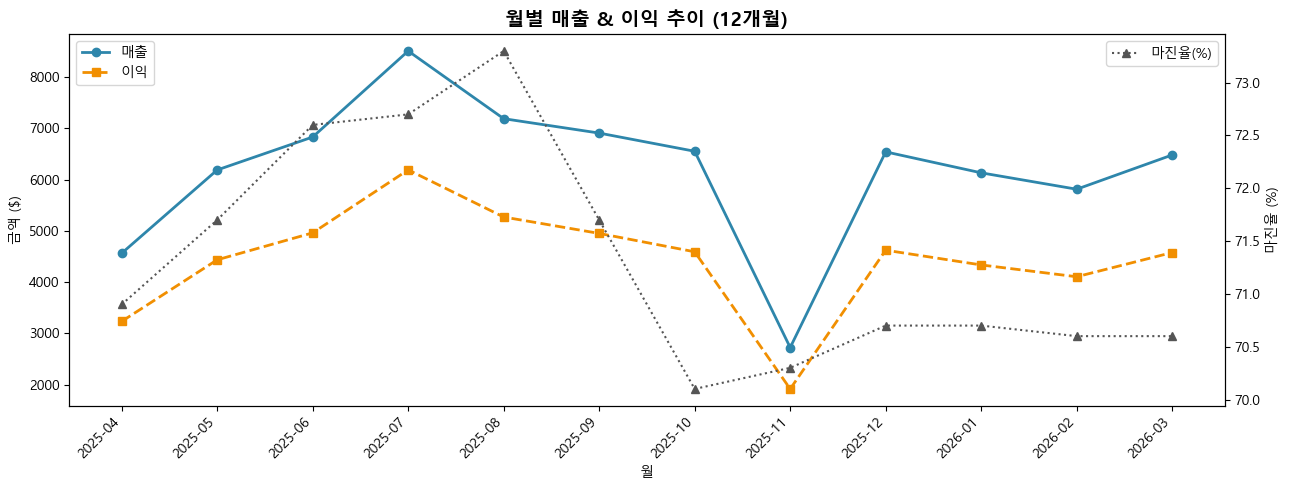

저장: G:\내 드라이브\강의자료\Vibe_Coding\Datascience\Test\15_Basecamp_Brew_Analysis\output\01_monthly_trend.png


In [10]:
fig, ax1 = plt.subplots(figsize=(13, 5))

x = range(len(monthly))
ax1.plot(x, monthly['Revenue'], 'o-', color='#2E86AB', linewidth=2, label='매출')
ax1.plot(x, monthly['Profit'],  's--', color='#F18F01', linewidth=2, label='이익')
ax1.set_xlabel('월')
ax1.set_ylabel('금액 ($)')
ax1.set_xticks(x)
ax1.set_xticklabels(monthly['MonthName'], rotation=45, ha='right')
ax1.legend(loc='upper left')

# 마진율 우측 Y축
ax2 = ax1.twinx()
ax2.plot(x, monthly['ProfitMargin_Pct'], '^:', color='#555555', linewidth=1.5, label='마진율(%)')
ax2.set_ylabel('마진율 (%)')
ax2.legend(loc='upper right')

plt.title('월별 매출 & 이익 추이 (12개월)', fontsize=14, fontweight='bold')
plt.tight_layout()
out1 = os.path.join(OUTPUT_DIR, '01_monthly_trend.png')
plt.savefig(out1, dpi=150, bbox_inches='tight')
plt.show()
print(f"저장: {out1}")

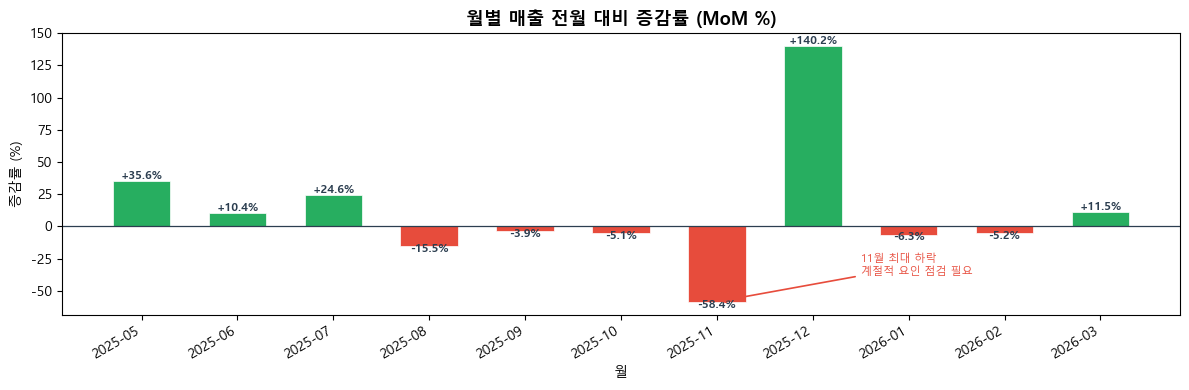

저장: G:\내 드라이브\강의자료\Vibe_Coding\Datascience\Test\15_Basecamp_Brew_Analysis\output\01b_monthly_mom.png


In [11]:
# ── 월별 MoM 증감률 막대 차트 ────────────────────────────
monthly_mom = monthly.dropna(subset=['Revenue_MoM_Pct']).copy()
colors_mom = ['#27ae60' if v >= 0 else '#e74c3c' for v in monthly_mom['Revenue_MoM_Pct']]

fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(monthly_mom['MonthName'], monthly_mom['Revenue_MoM_Pct'],
              color=colors_mom, edgecolor='white', linewidth=0.5, width=0.6)
ax.axhline(0, color='#2c3e50', linewidth=0.9)

for bar, val in zip(bars, monthly_mom['Revenue_MoM_Pct']):
    ypos = bar.get_height() + 1.5 if val >= 0 else bar.get_height() - 4.5
    ax.text(bar.get_x() + bar.get_width()/2, ypos,
            f'{val:+.1f}%', ha='center', fontsize=8.5, fontweight='600', color='#2c3e50')

# 11월 주석
idx_nov = monthly_mom[monthly_mom['MonthName'] == '2025-11'].index
if len(idx_nov) > 0:
    pos_nov = list(monthly_mom.index).index(idx_nov[0])
    ax.annotate('11월 최대 하락\n계절적 요인 점검 필요',
                xy=(pos_nov, -58.4), xytext=(pos_nov + 1.5, -38),
                fontsize=8, color='#e74c3c',
                arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=1.2))

ax.set_title('월별 매출 전월 대비 증감률 (MoM %)', fontsize=13, fontweight='bold')
ax.set_xlabel('월')
ax.set_ylabel('증감률 (%)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
out_mom = os.path.join(OUTPUT_DIR, '01b_monthly_mom.png')
plt.savefig(out_mom, dpi=150, bbox_inches='tight')
plt.show()
print(f"저장: {out_mom}")

## § 3. 채널별 성과

In [12]:
channel = channel_summary(df_sales)

disp = channel[['Channel', 'Orders', 'Revenue', 'Profit', 'AvgOrderValue', 'ProfitMargin_Pct', 'RevenueShare_Pct']].copy()
disp.columns = ['채널', '주문수', '총매출', '총이익', '객단가', '마진(%)', '매출비중(%)']
disp['총매출'] = disp['총매출'].apply(fmt_dollar)
disp['총이익'] = disp['총이익'].apply(fmt_dollar)
disp['객단가'] = disp['객단가'].apply(fmt_dollar)
print(disp.to_string(index=False))

             채널  주문수        총매출        총이익     객단가  마진(%)  매출비중(%)
         Online  180 $33,832.00 $23,943.30 $187.96   70.8     45.5
  Downtown Shop  180 $24,672.00 $17,794.00 $137.07   72.1     33.1
     Mall Kiosk  180  $9,001.00  $6,478.60  $50.01   72.0     12.1
Farmer's Market   90  $6,923.00  $4,966.10  $76.92   71.7      9.3


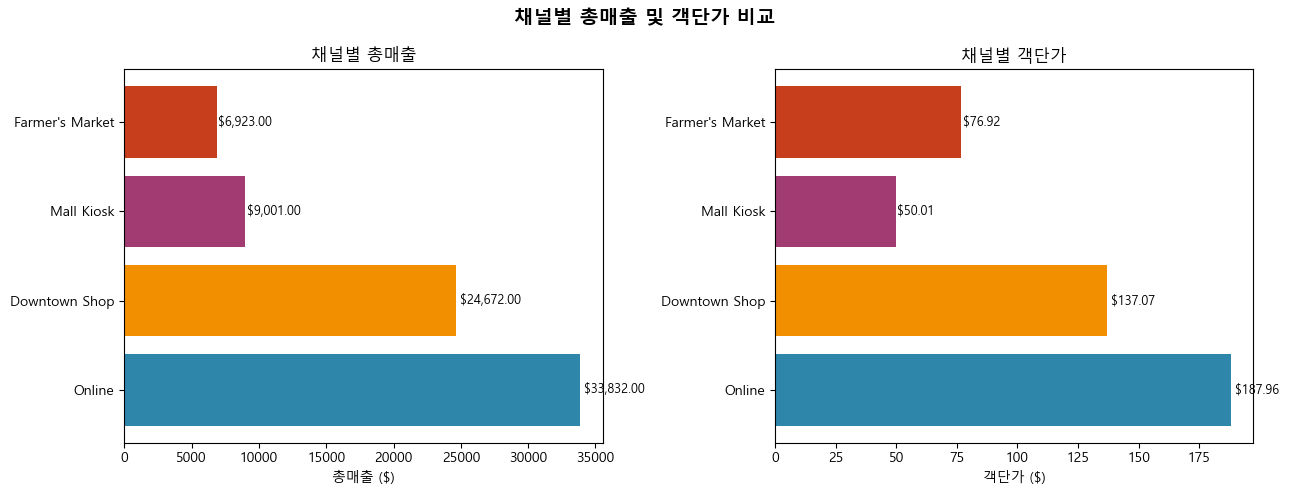

저장: G:\내 드라이브\강의자료\Vibe_Coding\Datascience\Test\15_Basecamp_Brew_Analysis\output\02_channel_performance.png


In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

colors = [CHANNEL_COLORS.get(c, '#888888') for c in channel['Channel']]

# 좌: 총매출
ax1.barh(channel['Channel'], channel['Revenue'], color=colors)
ax1.set_xlabel('총매출 ($)')
ax1.set_title('채널별 총매출')
for i, v in enumerate(channel['Revenue']):
    ax1.text(v * 1.01, i, fmt_dollar(v), va='center', fontsize=9)

# 우: 객단가
ax2.barh(channel['Channel'], channel['AvgOrderValue'], color=colors)
ax2.set_xlabel('객단가 ($)')
ax2.set_title('채널별 객단가')
for i, v in enumerate(channel['AvgOrderValue']):
    ax2.text(v * 1.01, i, fmt_dollar(v), va='center', fontsize=9)

plt.suptitle('채널별 총매출 및 객단가 비교', fontsize=14, fontweight='bold')
plt.tight_layout()
out2 = os.path.join(OUTPUT_DIR, '02_channel_performance.png')
plt.savefig(out2, dpi=150, bbox_inches='tight')
plt.show()
print(f"저장: {out2}")

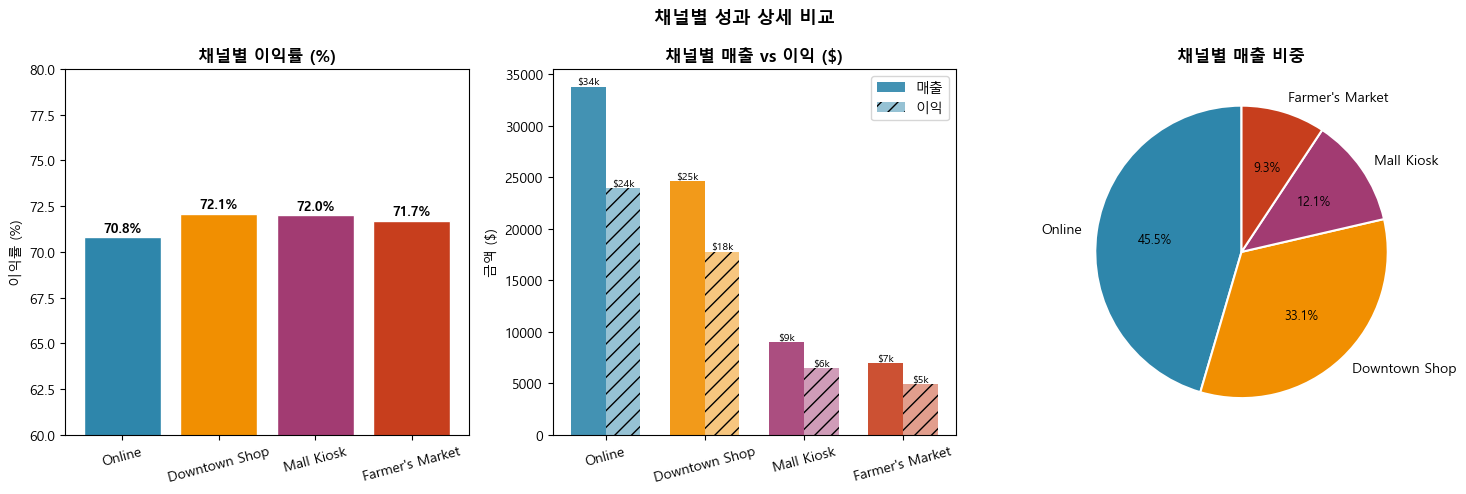

저장: G:\내 드라이브\강의자료\Vibe_Coding\Datascience\Test\15_Basecamp_Brew_Analysis\output\02b_channel_detail.png


In [14]:
# ── 채널별 상세 비교 — 마진율 / 매출 vs 이익 / 비중 ────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
ch_names = channel['Channel'].tolist()
colors_ch = [CHANNEL_COLORS.get(c, '#888') for c in ch_names]

# 1) 마진율 수직 막대
axes[0].bar(ch_names, channel['ProfitMargin_Pct'], color=colors_ch, edgecolor='white')
axes[0].set_ylim(60, 80)
axes[0].set_title('채널별 이익률 (%)', fontweight='bold')
axes[0].set_ylabel('이익률 (%)')
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(channel['ProfitMargin_Pct']):
    axes[0].text(i, v + 0.3, f'{v}%', ha='center', fontsize=9.5, fontweight='bold')

# 2) 매출 vs 이익 그룹드 바
x = list(range(len(ch_names)))
w = 0.35
axes[1].bar([i - w/2 for i in x], channel['Revenue'], w, label='매출', color=colors_ch, alpha=0.9)
axes[1].bar([i + w/2 for i in x], channel['Profit'], w, label='이익',
            color=colors_ch, alpha=0.5, hatch='//')
axes[1].set_xticks(x)
axes[1].set_xticklabels(ch_names, rotation=15)
axes[1].set_title('채널별 매출 vs 이익 ($)', fontweight='bold')
axes[1].set_ylabel('금액 ($)')
axes[1].legend()
for i, (rev, pft) in enumerate(zip(channel['Revenue'], channel['Profit'])):
    axes[1].text(i - w/2, rev + 200, f'${rev/1000:.0f}k', ha='center', fontsize=7.5)
    axes[1].text(i + w/2, pft + 200, f'${pft/1000:.0f}k', ha='center', fontsize=7.5)

# 3) 매출 비중 파이
wedges, texts, autotexts = axes[2].pie(
    channel['Revenue'], labels=ch_names, autopct='%1.1f%%',
    colors=colors_ch, startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=1.5))
for at in autotexts:
    at.set_fontsize(9)
axes[2].set_title('채널별 매출 비중', fontweight='bold')

plt.suptitle('채널별 성과 상세 비교', fontsize=13, fontweight='bold')
plt.tight_layout()
out_ch2 = os.path.join(OUTPUT_DIR, '02b_channel_detail.png')
plt.savefig(out_ch2, dpi=150, bbox_inches='tight')
plt.show()
print(f"저장: {out_ch2}")

## § 4. 제품 & 카테고리 분석

In [15]:
products = product_summary(df_sales)
top10 = products.head(10)

disp = top10[['Product', 'Category', 'Orders', 'Revenue', 'Profit', 'ProfitMargin_Pct']].copy()
disp.columns = ['제품', '카테고리', '주문수', '매출', '이익', '마진(%)']
disp['매출'] = disp['매출'].apply(fmt_dollar)
disp['이익'] = disp['이익'].apply(fmt_dollar)
print("[Top 10 제품]")
print(disp.to_string(index=False))

print("\n[최하위 3개 제품]")
bot3 = products.tail(3)[['Product', 'Category', 'Revenue', 'ProfitMargin_Pct']].copy()
bot3['Revenue'] = bot3['Revenue'].apply(fmt_dollar)
print(bot3.to_string(index=False))

[Top 10 제품]
                         제품      카테고리  주문수         매출         이익  마진(%)
Bean Subscription (Monthly)     Beans   42 $24,048.00 $17,034.00   70.8
 Single Origin Beans (340g)     Beans   42 $12,452.00  $7,924.00   63.6
   House Blend Beans (340g)     Beans   42  $9,936.00  $6,624.00   66.7
                 Iced Latte Cold Brew   42  $3,971.00  $3,032.40   76.4
                  Cold Brew Cold Brew   42  $3,585.00  $3,011.40   84.0
            Nitro Cold Brew Cold Brew   42  $3,564.00  $2,970.00   83.3
                    T-Shirt     Merch   42  $2,772.00  $1,980.00   71.4
                      Latte  Espresso   42  $2,348.50  $1,708.00   72.7
                 Cappuccino  Espresso   42  $2,140.00  $1,540.80   72.0
                   Espresso  Espresso   42  $2,007.00  $1,471.80   73.3

[최하위 3개 제품]
    Product Category   Revenue  ProfitMargin_Pct
   Tote Bag    Merch $1,610.00              78.6
  Pour Over     Drip $1,471.50              80.0
Drip Coffee     Drip $1,023.00      

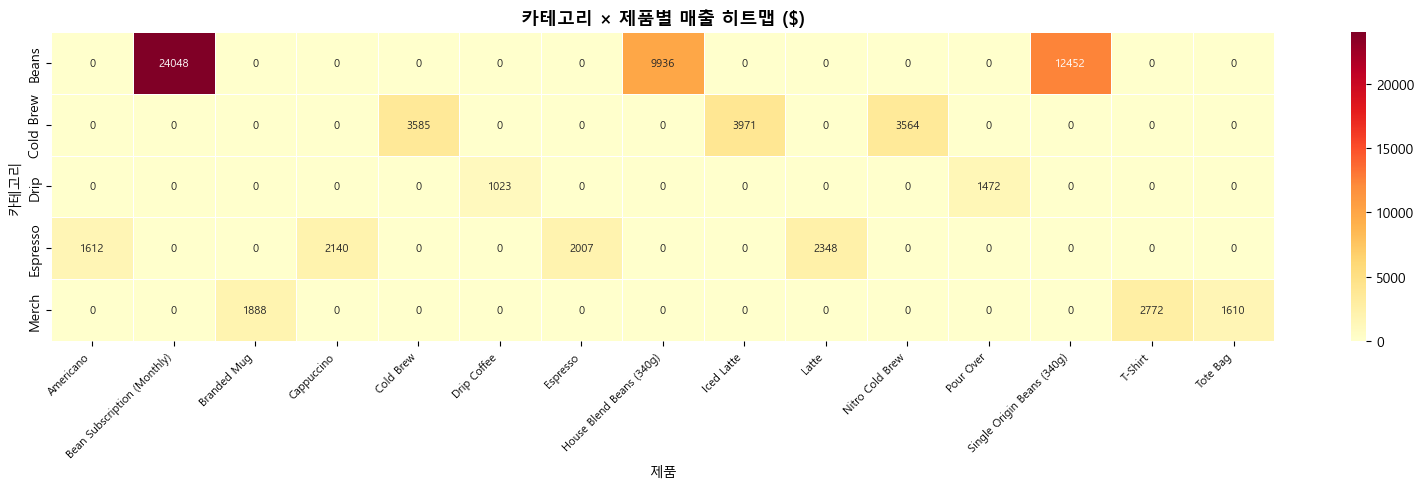

저장: G:\내 드라이브\강의자료\Vibe_Coding\Datascience\Test\15_Basecamp_Brew_Analysis\output\03_product_heatmap.png


In [16]:
# 카테고리×제품 매출 피벗
pivot = products.pivot_table(values='Revenue', index='Category', columns='Product', fill_value=0)

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, linecolor='white',
            annot_kws={"size": 8})
ax.set_title('카테고리 × 제품별 매출 히트맵 ($)', fontsize=13, fontweight='bold')
ax.set_xlabel('제품')
ax.set_ylabel('카테고리')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
out3 = os.path.join(OUTPUT_DIR, '03_product_heatmap.png')
plt.savefig(out3, dpi=150, bbox_inches='tight')
plt.show()
print(f"저장: {out3}")

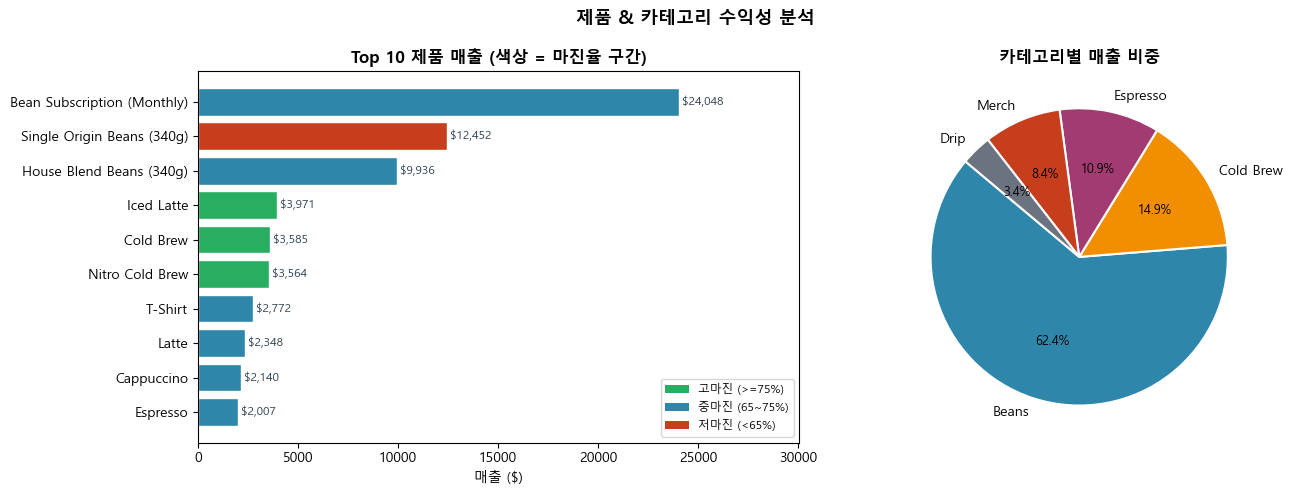

저장: G:\내 드라이브\강의자료\Vibe_Coding\Datascience\Test\15_Basecamp_Brew_Analysis\output\03b_product_analysis.png


In [17]:
# ── 제품 Top 10 수평 막대 + 카테고리별 파이 ────────────
from matplotlib.patches import Patch

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

top10_p = products.head(10)
# 마진율 구간별 색상
bar_colors = ['#27ae60' if m >= 75 else '#2E86AB' if m >= 65 else '#C73E1D'
              for m in top10_p['ProfitMargin_Pct']]
bars = ax1.barh(top10_p['Product'][::-1], top10_p['Revenue'][::-1],
                color=bar_colors[::-1], edgecolor='white')
for bar, val in zip(bars, top10_p['Revenue'][::-1]):
    ax1.text(bar.get_width() + 150, bar.get_y() + bar.get_height()/2,
             f'${val:,.0f}', va='center', fontsize=8.5, color='#2c3e50')
ax1.set_title('Top 10 제품 매출 (색상 = 마진율 구간)', fontweight='bold')
ax1.set_xlabel('매출 ($)')
ax1.set_xlim(0, top10_p['Revenue'].max() * 1.25)
legend_elements = [
    Patch(facecolor='#27ae60', label='고마진 (>=75%)'),
    Patch(facecolor='#2E86AB', label='중마진 (65~75%)'),
    Patch(facecolor='#C73E1D', label='저마진 (<65%)'),
]
ax1.legend(handles=legend_elements, loc='lower right', fontsize=8.5)

# 카테고리별 매출 파이
cat_rev = products.groupby('Category')['Revenue'].sum().sort_values(ascending=False)
cat_colors = ['#2E86AB', '#F18F01', '#A23B72', '#C73E1D', '#6B7280'][:len(cat_rev)]
wedges, texts, autotexts = ax2.pie(
    cat_rev, labels=cat_rev.index, autopct='%1.1f%%',
    colors=cat_colors, startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=1.5))
for at in autotexts:
    at.set_fontsize(9)
ax2.set_title('카테고리별 매출 비중', fontweight='bold')

plt.suptitle('제품 & 카테고리 수익성 분석', fontsize=13, fontweight='bold')
plt.tight_layout()
out_p2 = os.path.join(OUTPUT_DIR, '03b_product_analysis.png')
plt.savefig(out_p2, dpi=150, bbox_inches='tight')
plt.show()
print(f"저장: {out_p2}")

## § 5. 고객 분석 (판매 데이터 교차)

In [18]:
if df_customers is not None:
    cust_seg = customer_segment_summary(df_customers)

    print("[채널×재구매 세그먼트]")
    disp = cust_seg.copy()
    disp['TotalSpend'] = disp['TotalSpend'].apply(fmt_dollar)
    disp['AvgSpend']   = disp['AvgSpend'].apply(fmt_dollar)
    disp.columns = ['채널', '재구매여부', '고객수', '총지출', '평균지출', '평균주문수']
    print(disp.to_string(index=False))

    print("\n[Top 10 최우수 고객 — Total Spend 기준]")
    top10_cust = df_customers.nlargest(10, 'Total Spend')[
        ['Customer ID', 'Name', 'Channel', 'Total Orders', 'Total Spend', 'Repeat Customer']
    ].copy()
    top10_cust['Total Spend'] = top10_cust['Total Spend'].apply(fmt_dollar)
    top10_cust.columns = ['ID', '이름', '채널', '주문수', '총지출', '재구매']
    print(top10_cust.to_string(index=False))
else:
    print("고객 데이터 없음 (CUSTOMERS_FILE=None)")

[채널×재구매 세그먼트]
             채널 재구매여부  고객수       총지출    평균지출  평균주문수
  Downtown Shop    No   54 $1,279.43  $23.69    2.1
  Downtown Shop   Yes   14 $2,785.26 $198.95   10.9
Farmer's Market    No   28   $861.39  $30.76    2.2
Farmer's Market   Yes    9 $2,951.19 $327.91   12.6
     Mall Kiosk    No   24   $684.73  $28.53    2.3
     Mall Kiosk   Yes    8 $1,867.74 $233.47   11.0
         Online    No   38   $995.02  $26.18    2.2
         Online   Yes   25 $8,077.12 $323.08   13.4

[Top 10 최우수 고객 — Total Spend 기준]
   ID        이름              채널  주문수     총지출 재구매
C-215   Alex F.          Online   22 $661.60 Yes
C-267  Jamie L. Farmer's Market   17 $574.63 Yes
C-192   Drew D.          Online   25 $571.49 Yes
C-188 Taylor E. Farmer's Market   23 $534.35 Yes
C-281 Hayden J.          Online   14 $468.99 Yes
C-136   Alex P. Farmer's Market   15 $451.92 Yes
C-211 Aubrey B.          Online   14 $449.30 Yes
C-231 Jordan L.          Online   16 $445.56 Yes
C-134 Aubrey S.          Online   13 $444.6

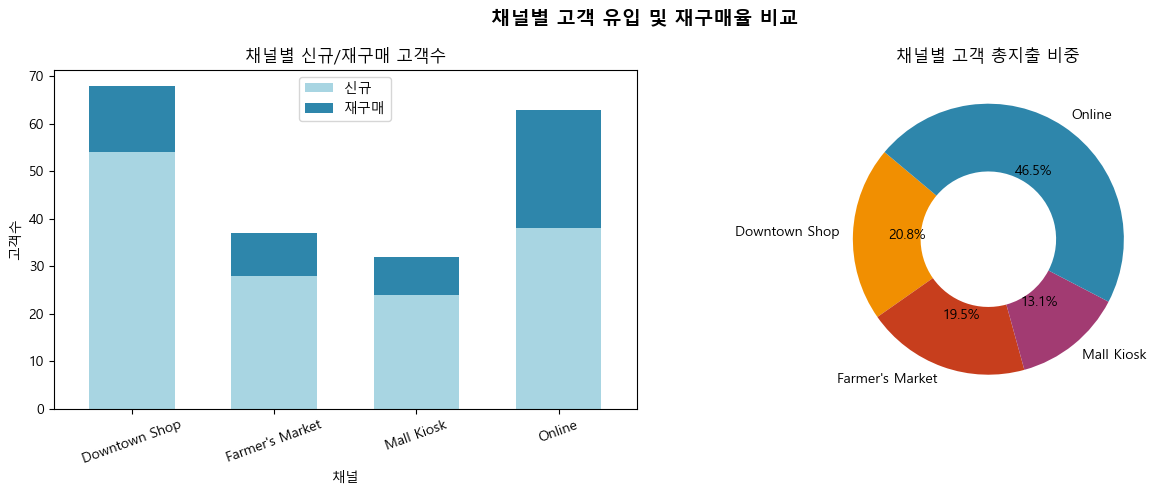

저장: G:\내 드라이브\강의자료\Vibe_Coding\Datascience\Test\15_Basecamp_Brew_Analysis\output\04_customer_channels.png


In [19]:
if df_customers is not None:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

    # 좌: 채널별 신규/재구매 스택드 바
    pivot_cust = df_customers.groupby(['Channel', 'Repeat Customer']).size().unstack(fill_value=0)
    colors_stack = ['#A8D5E2', '#2E86AB']
    pivot_cust.plot(kind='bar', stacked=True, ax=ax1, color=colors_stack, width=0.6)
    ax1.set_title('채널별 신규/재구매 고객수')
    ax1.set_xlabel('채널')
    ax1.set_ylabel('고객수')
    ax1.tick_params(axis='x', rotation=20)
    ax1.legend(['신규', '재구매'])

    # 우: 채널별 Total Spend 도넛 파이
    spend_by_channel = df_customers.groupby('Channel')['Total Spend'].sum()
    colors_pie = [CHANNEL_COLORS.get(c, '#888888') for c in spend_by_channel.index]
    wedges, texts, autotexts = ax2.pie(
        spend_by_channel, labels=spend_by_channel.index, autopct='%1.1f%%',
        colors=colors_pie, startangle=140,
        wedgeprops=dict(width=0.5)
    )
    ax2.set_title('채널별 고객 총지출 비중')

    plt.suptitle('채널별 고객 유입 및 재구매율 비교', fontsize=14, fontweight='bold')
    plt.tight_layout()
    out4 = os.path.join(OUTPUT_DIR, '04_customer_channels.png')
    plt.savefig(out4, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"저장: {out4}")

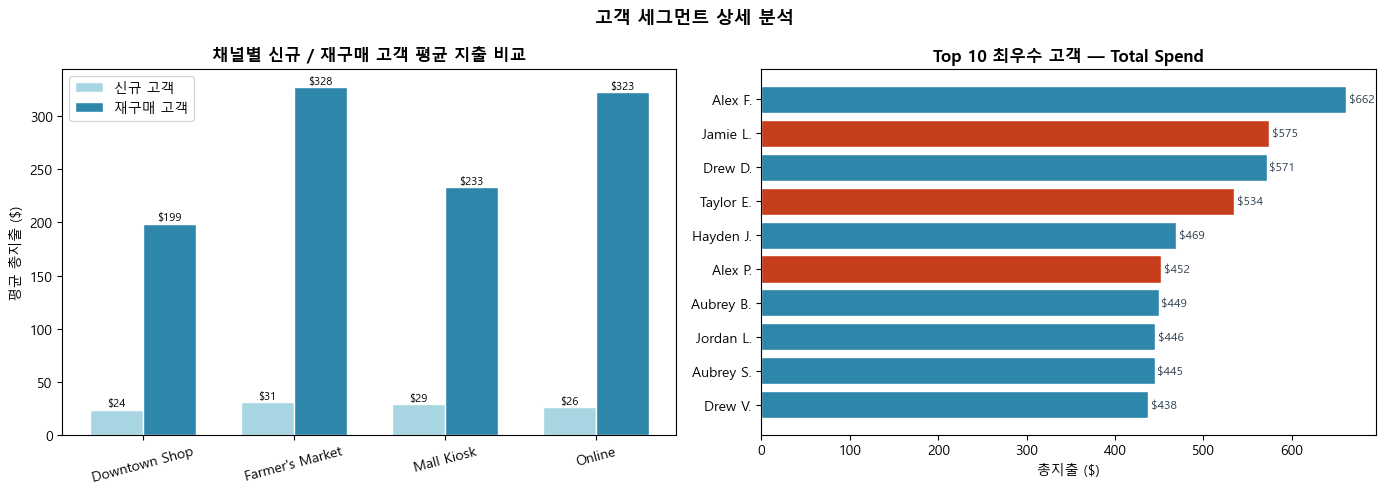

저장: G:\내 드라이브\강의자료\Vibe_Coding\Datascience\Test\15_Basecamp_Brew_Analysis\output\04b_customer_spend.png


In [20]:
# ── 고객 상세 분석 — 평균지출 비교 + Top 10 고객 막대 ──
if df_customers is not None:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # 왼쪽: 채널별 신규/재구매 평균지출 그룹드 바
    cust_pivot = (df_customers
                  .groupby(['Channel', 'Repeat Customer'])['Total Spend']
                  .mean()
                  .unstack(fill_value=0))
    ch_list = cust_pivot.index.tolist()
    x = list(range(len(ch_list)))
    w = 0.35
    no_vals  = cust_pivot.get('No',  [0]*len(x))
    yes_vals = cust_pivot.get('Yes', [0]*len(x))
    ax1.bar([i - w/2 for i in x], no_vals,  w, label='신규 고객',  color='#A8D5E2', edgecolor='white')
    ax1.bar([i + w/2 for i in x], yes_vals, w, label='재구매 고객', color='#2E86AB', edgecolor='white')
    ax1.set_xticks(x)
    ax1.set_xticklabels(ch_list, rotation=15)
    ax1.set_title('채널별 신규 / 재구매 고객 평균 지출 비교', fontweight='bold')
    ax1.set_ylabel('평균 총지출 ($)')
    ax1.legend()
    for i, (nv, yv) in enumerate(zip(no_vals, yes_vals)):
        ax1.text(i - w/2, nv + 3,  f'${nv:.0f}',  ha='center', fontsize=8)
        ax1.text(i + w/2, yv + 3,  f'${yv:.0f}',  ha='center', fontsize=8)

    # 오른쪽: Top 10 고객 수평 막대
    top10_c = df_customers.nlargest(10, 'Total Spend')
    bar_c = [CHANNEL_COLORS.get(c, '#888') for c in top10_c['Channel']]
    ax2.barh(top10_c['Name'][::-1], top10_c['Total Spend'][::-1],
             color=bar_c[::-1], edgecolor='white')
    for i, (nm, val) in enumerate(zip(top10_c['Name'][::-1], top10_c['Total Spend'][::-1])):
        ax2.text(val + 3, i, f'${val:.0f}', va='center', fontsize=8.5, color='#2c3e50')
    ax2.set_title('Top 10 최우수 고객 — Total Spend', fontweight='bold')
    ax2.set_xlabel('총지출 ($)')

    plt.suptitle('고객 세그먼트 상세 분석', fontsize=13, fontweight='bold')
    plt.tight_layout()
    out_c2 = os.path.join(OUTPUT_DIR, '04b_customer_spend.png')
    plt.savefig(out_c2, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"저장: {out_c2}")

## § 6. 이상값 & 주목할 패턴

Revenue IQR 상한: $233.00
고매출 이상 주문 88건:
Order ID       Date                     Product       Channel  Quantity  Revenue
 BB-1483 2025-12-30 Bean Subscription (Monthly)        Online        78   1872.0
 BB-1528 2026-01-04 Bean Subscription (Monthly)        Online        67   1608.0
 BB-1573 2026-02-02 Bean Subscription (Monthly)        Online        61   1464.0
 BB-1618 2026-03-26 Bean Subscription (Monthly)        Online        57   1368.0
 BB-1389 2025-10-28 Bean Subscription (Monthly)        Online        43   1032.0
 BB-1209 2025-07-01 Bean Subscription (Monthly)        Online        39    936.0
 BB-1619 2026-03-30 Bean Subscription (Monthly) Downtown Shop        37    888.0
 BB-1089 2025-05-28 Bean Subscription (Monthly)        Online        36    864.0
 BB-1269 2025-08-16 Bean Subscription (Monthly)        Online        35    840.0
 BB-1329 2025-09-29 Bean Subscription (Monthly)        Online        34    816.0


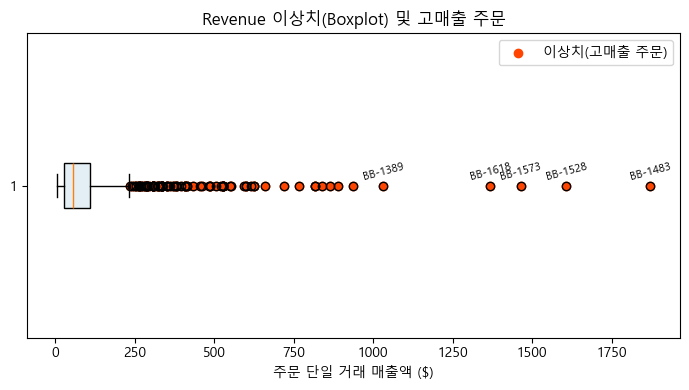

저장: G:\내 드라이브\강의자료\Vibe_Coding\Datascience\Test\15_Basecamp_Brew_Analysis\output\05_outlier_revenue.png

최고 매출 월: 2025-07 — $8,509.00
최저 매출 월: 2025-11 — $2,723.00
최고 채널: Online — $33,832.00 (비중 45.5%)
최고 제품: Bean Subscription (Monthly) — $24,048.00


In [21]:
# Revenue IQR 이상치 상세
rev = df_sales['Revenue']
q1, q3 = rev.quantile(0.25), rev.quantile(0.75)
iqr = q3 - q1
upper = q3 + 1.5 * iqr
outlier_orders = df_sales[rev > upper].sort_values('Revenue', ascending=False)
print(f"Revenue IQR 상한: {fmt_dollar(upper)}")
if len(outlier_orders) > 0:
    print(f"고매출 이상 주문 {len(outlier_orders)}건:")
    print(outlier_orders[['Order ID', 'Date', 'Product', 'Channel', 'Quantity', 'Revenue']].head(10).to_string(index=False))
else:
    print("Revenue IQR 이상치: 없음")

# 이상치 탐지 시각화: boxplot, 이상치 라벨링 표시
plt.figure(figsize=(7, 4))
plt.boxplot(rev, vert=False, patch_artist=True, boxprops=dict(facecolor="#E3EEF5"))
plt.scatter(outlier_orders['Revenue'], np.ones(len(outlier_orders)), color='orangered', label='이상치(고매출 주문)')
for idx, row in outlier_orders.head(5).iterrows():
    plt.annotate(f"{row['Order ID']}", (row['Revenue'], 1.01),
                 fontsize=8, color='black', ha='center', va='bottom', rotation=15)
plt.xlabel('주문 단일 거래 매출액 ($)')
plt.title('Revenue 이상치(Boxplot) 및 고매출 주문')
plt.legend()
out_path = os.path.join(OUTPUT_DIR, '05_outlier_revenue.png')
plt.tight_layout()
plt.savefig(out_path, dpi=130)
plt.show()
print(f"저장: {out_path}")

# 주요 인사이트 수치
best_month = monthly.loc[monthly['Revenue'].idxmax()]
worst_month = monthly.loc[monthly['Revenue'].idxmin()]
best_channel = channel.iloc[0]
best_product = products.iloc[0]
print(f"\n최고 매출 월: {best_month['MonthName']} — {fmt_dollar(best_month['Revenue'])}")
print(f"최저 매출 월: {worst_month['MonthName']} — {fmt_dollar(worst_month['Revenue'])}")
print(f"최고 채널: {best_channel['Channel']} — {fmt_dollar(best_channel['Revenue'])} (비중 {best_channel['RevenueShare_Pct']}%)")
print(f"최고 제품: {best_product['Product']} — {fmt_dollar(best_product['Revenue'])}")

In [22]:
# 종합 요약 지표
total_revenue = df_sales['Revenue'].sum()
total_profit  = df_sales['Profit'].sum()
avg_margin    = (total_profit / total_revenue * 100)
repeat_rate   = (df_customers['Repeat Customer'].eq('Yes').mean() * 100) if df_customers is not None else None

print("=" * 55)
print("  Basecamp Brew Co. — 12개월 종합 요약")
print("=" * 55)
print(f"  총 매출       : {fmt_dollar(total_revenue)}")
print(f"  총 이익       : {fmt_dollar(total_profit)}")
print(f"  평균 마진율   : {avg_margin:.1f}%")
print(f"  총 주문수     : {len(df_sales):,}건")
print(f"  최고 채널     : {channel.iloc[0]['Channel']} ({fmt_dollar(channel.iloc[0]['Revenue'])})")
print(f"  최고 제품     : {products.iloc[0]['Product']} ({fmt_dollar(products.iloc[0]['Revenue'])})")
if repeat_rate is not None:
    print(f"  재구매율      : {repeat_rate:.1f}%")
print("=" * 55)

  Basecamp Brew Co. — 12개월 종합 요약
  총 매출       : $74,428.00
  총 이익       : $53,182.00
  평균 마진율   : 71.5%
  총 주문수     : 630건
  최고 채널     : Online ($33,832.00)
  최고 제품     : Bean Subscription (Monthly) ($24,048.00)
  재구매율      : 28.0%


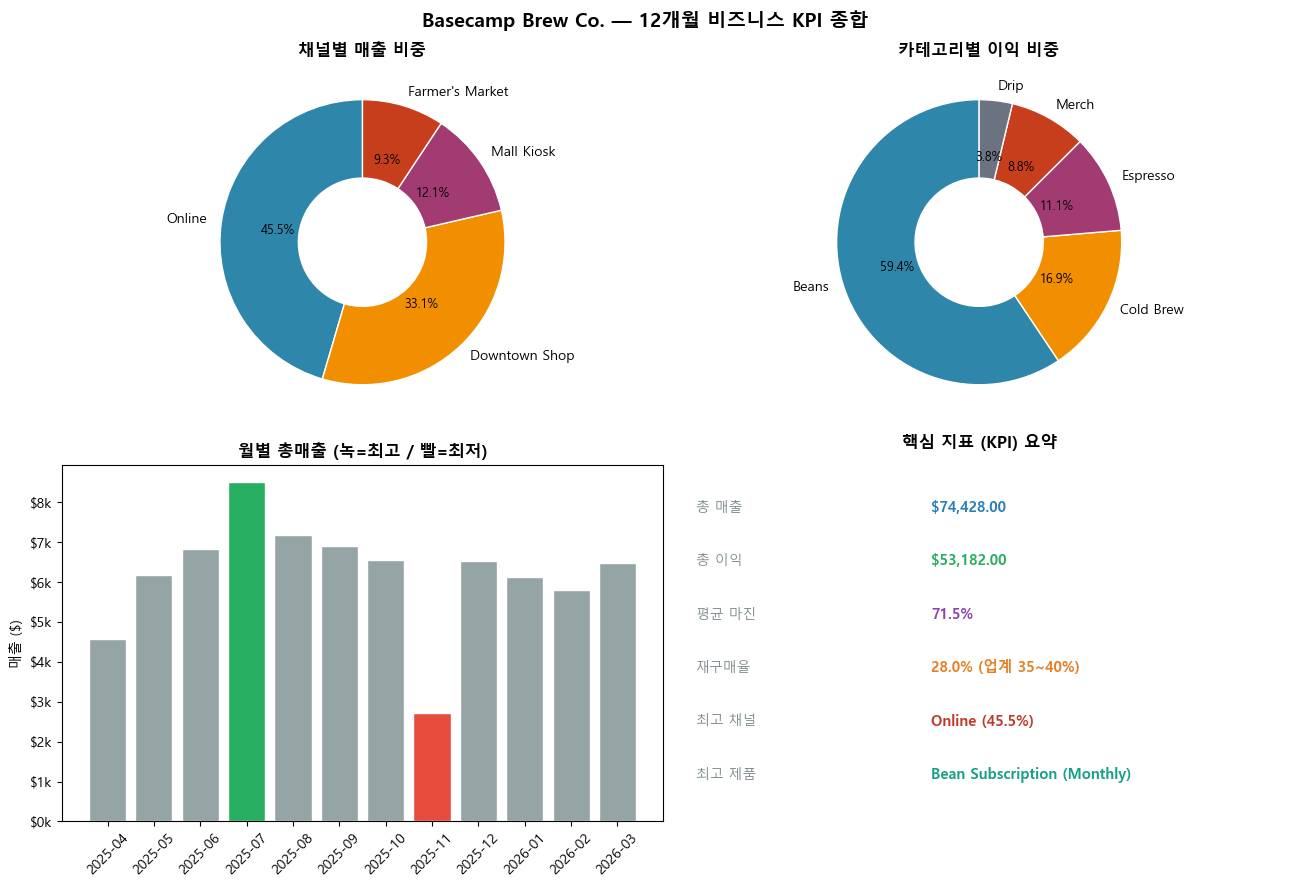

저장: G:\내 드라이브\강의자료\Vibe_Coding\Datascience\Test\15_Basecamp_Brew_Analysis\output\06_summary_kpi.png


In [23]:
# ── 종합 KPI 요약 시각화 (2x2) ─────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('Basecamp Brew Co. — 12개월 비즈니스 KPI 종합', fontsize=14, fontweight='bold')

# (0,0) 채널별 매출 비중 도넛
ch_colors_list = [CHANNEL_COLORS.get(c, '#888') for c in channel['Channel']]
wedges, texts, autotexts = axes[0,0].pie(
    channel['Revenue'], labels=channel['Channel'], autopct='%1.1f%%',
    colors=ch_colors_list, startangle=90,
    wedgeprops=dict(width=0.55, edgecolor='white'))
for at in autotexts:
    at.set_fontsize(9)
axes[0,0].set_title('채널별 매출 비중', fontweight='bold')

# (0,1) 카테고리별 이익 도넛
cat_pft = products.groupby('Category')['Profit'].sum().sort_values(ascending=False)
cat_cols = ['#2E86AB','#F18F01','#A23B72','#C73E1D','#6B7280'][:len(cat_pft)]
wedges2, texts2, autotexts2 = axes[0,1].pie(
    cat_pft, labels=cat_pft.index, autopct='%1.1f%%',
    colors=cat_cols, startangle=90,
    wedgeprops=dict(width=0.55, edgecolor='white'))
for at in autotexts2:
    at.set_fontsize(9)
axes[0,1].set_title('카테고리별 이익 비중', fontweight='bold')

# (1,0) 월별 매출 막대 (최고=녹, 최저=빨)
bar_colors_m = ['#95a5a6'] * len(monthly)
bar_colors_m[int(monthly['Revenue'].idxmax())] = '#27ae60'
bar_colors_m[int(monthly['Revenue'].idxmin())] = '#e74c3c'
axes[1,0].bar(monthly['MonthName'], monthly['Revenue'], color=bar_colors_m, edgecolor='white')
axes[1,0].set_title('월별 총매출 (녹=최고 / 빨=최저)', fontweight='bold')
axes[1,0].set_ylabel('매출 ($)')
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].yaxis.set_major_formatter(
    matplotlib.ticker.FuncFormatter(lambda v, _: f'${v/1000:.0f}k'))

# (1,1) KPI 텍스트 카드
axes[1,1].axis('off')
kpis = [
    ('총 매출',   fmt_dollar(total_revenue),              '#2980b9'),
    ('총 이익',   fmt_dollar(total_profit),               '#27ae60'),
    ('평균 마진', f'{avg_margin:.1f}%',                   '#8e44ad'),
    ('재구매율',  f'{repeat_rate:.1f}% (업계 35~40%)',    '#e67e22'),
    ('최고 채널', f'{channel.iloc[0]["Channel"]} ({channel.iloc[0]["RevenueShare_Pct"]}%)', '#c0392b'),
    ('최고 제품', products.iloc[0]['Product'],             '#16a085'),
]
for i, (lbl, val, col) in enumerate(kpis):
    y = 0.88 - i * 0.15
    axes[1,1].text(0.03, y, lbl, fontsize=10, color='#7f8c8d',
                   transform=axes[1,1].transAxes, va='center')
    axes[1,1].text(0.42, y, val, fontsize=10.5, fontweight='bold', color=col,
                   transform=axes[1,1].transAxes, va='center')
axes[1,1].set_title('핵심 지표 (KPI) 요약', fontweight='bold', pad=12)

plt.tight_layout()
out_kpi = os.path.join(OUTPUT_DIR, '06_summary_kpi.png')
plt.savefig(out_kpi, dpi=150, bbox_inches='tight')
plt.show()
print(f"저장: {out_kpi}")

In [24]:
# 실제 데이터 기반 Top 3 비즈니스 액션 아이템
top_ch   = channel.iloc[0]
low_ch   = channel.iloc[-1]
best_prd = products.iloc[0]
low_margin_prd = products.sort_values('ProfitMargin_Pct').iloc[0]

print("\n" + "=" * 75)
print("  Top 3 비즈니스 액션 아이템")
print("=" * 75)

action1 = (
    f"[1] 최고 채널 집중 투자\n"
    f"    {top_ch['Channel']} 채널: 전체 매출 {top_ch['RevenueShare_Pct']}% ({fmt_dollar(top_ch['Revenue'])})\n"
    f"    객단가({fmt_dollar(top_ch['AvgOrderValue'])}) 업셀링 캠페인 우선 배정\n"
    f"    -> 객단가 10% 상승 시 추가 매출 +{fmt_dollar(top_ch['Revenue']*0.10)}"
)
action2 = (
    f"[2] 최우수 제품 재고 & 프로모션 강화\n"
    f"    {best_prd['Product']} ({best_prd['Category']}): {fmt_dollar(best_prd['Revenue'])} 최고 매출\n"
    f"    번들 패키지 / 구독 모델로 재구매 유도\n"
    f"    -> 재구매 10%p 향상 시 해당 제품 매출 +10%"
)
rr_str = f"{repeat_rate:.1f}" if repeat_rate is not None else "N/A"
action3 = (
    f"[3] 재구매 고객 전환율 제고\n"
    f"    현재 재구매율 {rr_str}% (업계 평균 35~40% 대비 낮음)\n"
    f"    로열티 프로그램 도입, {fmt_dollar(low_ch['AvgOrderValue'])} 이하 쿠폰 발송\n"
    f"    -> 재구매율 5%p 개선 시 LTV 약 10~15% 향상"
)
print(action1)
print()
print(action2)
print()
print(action3)
print("=" * 75)
print("\n분석 완료.")


  Top 3 비즈니스 액션 아이템
[1] 최고 채널 집중 투자
    Online 채널: 전체 매출 45.5% ($33,832.00)
    객단가($187.96) 업셀링 캠페인 우선 배정
    -> 객단가 10% 상승 시 추가 매출 +$3,383.20

[2] 최우수 제품 재고 & 프로모션 강화
    Bean Subscription (Monthly) (Beans): $24,048.00 최고 매출
    번들 패키지 / 구독 모델로 재구매 유도
    -> 재구매 10%p 향상 시 해당 제품 매출 +10%

[3] 재구매 고객 전환율 제고
    현재 재구매율 28.0% (업계 평균 35~40% 대비 낮음)
    로열티 프로그램 도입, $76.92 이하 쿠폰 발송
    -> 재구매율 5%p 개선 시 LTV 약 10~15% 향상

분석 완료.
